In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [4]:
from src.misc.metrics import *

result_folder = "results/RTX-A6000/llama3.2-vision_11b-qwen2.5_3b"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

{'task_completion_rate': 1,
 'task_success_rate': 0.03434343434343434,
 'total_execution_time': 16427.679465,
 'mean_execution_time': 8.296807810606062,
 'total_tasks': 1980,
 'DB_QUERY_TOOL_NOT_INITIALIZED': 838,
 'OCR_TOOL_NOT_INITIALIZED': 564,
 'DB_UPDATE_TOOL_NOT_INITIALIZED': 422,
 'DB_UPDATE_TOOL_ARGS_MISMATCH': 81,
 'SUCCESS': 68,
 'DB_QUERY_TOOL_ARGS_MISMATCH': 7}

In [5]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,full_logs,total_time,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,OCR_TOOL_NOT_INITIALIZED,"{""content"": ""DONE""}",2025-04-03 21:15:16.263329,2025-04-03 21:16:45.654842,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",89.3915,9,2958,2836,122,0.0,SUCCESS,89.391513,0 days 00:01:29
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,OCR_TOOL_NOT_INITIALIZED,ERROR Email does not contain any invoice infor...,2025-04-03 21:16:45.665058,2025-04-03 21:16:53.979336,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",8.3143,16,7346,7045,301,0.0,ERROR,8.314278,0 days 00:00:08
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,OCR_TOOL_NOT_INITIALIZED,"{""content"": ""DONE""}",2025-04-03 21:16:53.989363,2025-04-03 21:16:58.754211,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",4.7648,9,2875,2739,136,0.0,SUCCESS,4.764848,0 days 00:00:04
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,OCR_TOOL_NOT_INITIALIZED,"{""content"": ""DONE""}",2025-04-03 21:16:58.762659,2025-04-03 21:17:02.582731,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",3.8201,7,2221,2101,120,0.0,SUCCESS,3.820072,0 days 00:00:03
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,OCR_TOOL_NOT_INITIALIZED,"{""content"": ""DONE""}",2025-04-03 21:17:02.591063,2025-04-03 21:17:05.169682,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",2.5786,5,1500,1445,55,0.0,SUCCESS,2.578619,0 days 00:00:02


In [6]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

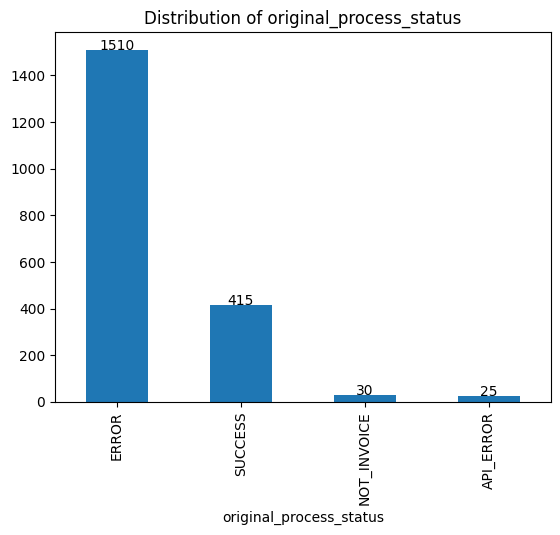

In [7]:
plot_value_distribution(df, "original_process_status")

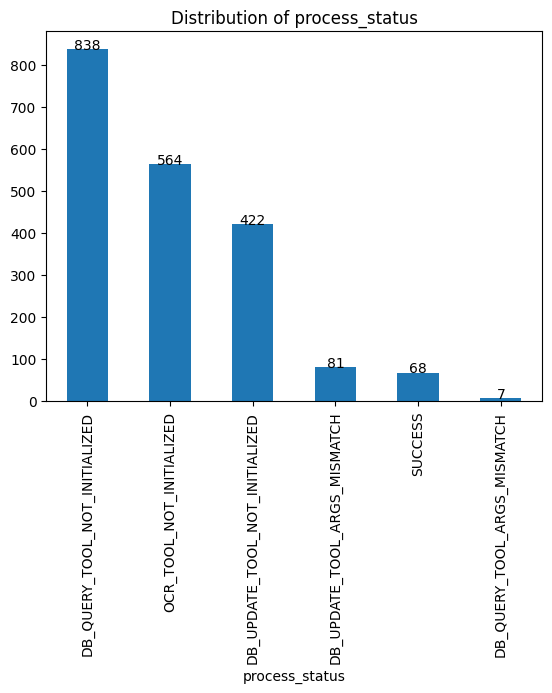

In [8]:
plot_value_distribution(df, "process_status")

In [9]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: OCR_TOOL_NOT_INITIALIZED
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-04-03 21:15:16.263329
--------------------------------------------------
end_time: 2025-04-03 21:16:45.654842
------------------------

In [10]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

12

In [11]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-03T21:15:16.263329",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "NO ATTACHMENTS",
    "timestamp": "2025-04-03T21:16:41.797611",
    "usa

In [12]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"43925\", \"bank_name\": \"Bank 538\", \"transaction_id\": \"EC4F9FE854344D25\", \"amount\": \"$196.00\", \"recipient_name\": \"Tanya\", \"sender_name\": \"Robin Levine\"}}",
    "timestamp": "2025-04-03T21:16:44.648781",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_update_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"DONE\"}",
    "timestamp": "2025-04-03T21:16:45.652828",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
       

2

In [13]:
df["process_status"].value_counts()

process_status
DB_QUERY_TOOL_NOT_INITIALIZED     838
OCR_TOOL_NOT_INITIALIZED          564
DB_UPDATE_TOOL_NOT_INITIALIZED    422
DB_UPDATE_TOOL_ARGS_MISMATCH       81
SUCCESS                            68
DB_QUERY_TOOL_ARGS_MISMATCH         7
Name: count, dtype: int64

In [16]:
df_filtered = (
    df[df["process_status"] == "DB_QUERY_TOOL_ARGS_MISMATCH"]
    .copy()
    .reset_index(drop=True)
)
len(df_filtered)

7

In [17]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: 7CB5914EF12B4F6F83E297AAB81960ED
--------------------------------------------------
sender_email: JeremiahGarcia@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 34699
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 34699 , Regards Jeremiah Garcia
--------------------------------------------------
attachments: transaction_691.jpeg
--------------------------------------------------
process_status: DB_QUERY_TOOL_ARGS_MISMATCH
--------------------------------------------------
response: ERROR - The invoice with ID 34699 is not found in the database. Please provide the missing data or contact the data engineer for further assistance.
--------------------------------------------------
start_time:

In [18]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

7

In [19]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: JeremiahGarcia@example.com\n            Subject: Payment Confirmation for Invoice ID: 34699\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 34699 , Regards Jeremiah Garcia\n            Attachment: transaction_691.jpeg\n            \n                ",
    "timestamp": "2025-04-03T22:33:23.763339",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-03T22:33:24.3

In [20]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 320\\nSent by: Jeremiah Garcia\\nYou paid $106 to Tanya\\nTransaction Reference Number: 9B171A824B6A4C3F\\nTransaction Date: 12/07/24\\nInvoice ID: 34699\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 143, \"prompt_tokens\": 90, \"completion_tokens\": 53, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-03T22:33:24.393948",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"No results\"}",
    "timestamp": "2025-04-03T22:33:27.770897",
    "usage": {
        "input_tokens": 0,
        "output_tok

2

In [21]:
logs[-1]

{'name': 'senior_reconciliation_agent',
 'type': 'AIMessage',
 'content': 'ERROR - The invoice with ID 34699 is not found in the database. Please provide the missing data or contact the data engineer for further assistance.',
 'timestamp': '2025-04-03T22:33:28.360982',
 'usage': {'input_tokens': 395,
  'output_tokens': 34,
  'total_tokens': 429,
  'input_token_details': {},
  'output_token_details': {}},
 'model_name': 'qwen2.5:3b',
 'additional_kwargs': {}}

In [22]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = -34699"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

0

In [23]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 34699"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [24]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 34699
--------------------------------------------------
bank_name: Bank 320
--------------------------------------------------
transaction_id: 9B171A824B6A4C3F
--------------------------------------------------
amount: 106.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: Jeremiah Garcia
--------------------------------------------------
reconciliation_state: UNPAID
--------------------------------------------------
email_details: 


In [25]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1616